# DQN vs PER-DQN: Comprehensive Online & Model-Based Offline Analysis

This notebook explores the efficiency and stability of Prioritized Experience Replay (PER).

**Project Phases:**
1. **Online Mastery:** Comparing DQN and PER-DQN on a sparse-reward 8x8 GridWorld.
2. **Model-Based Offline Training:** Using a Transition Probability Matrix (TPM) estimated from a 2,000-step random buffer to simulate "dreaming" or model-based learning.
3. **Comparative Post-Mortem:** Decoupling Model Collapse from Policy Collapse via Q-distribution analysis and heatmaps.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
import time
import copy
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import deque, namedtuple
from dataclasses import dataclass, field
from typing import List, Optional
from tqdm import tqdm

# --- Setup ---
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
sns.set_theme(style='darkgrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

def smooth(y, w=30): 
    if len(y) < w: return np.array(y)
    return np.convolve(y, np.ones(w)/w, mode='same')

Transition = namedtuple('Transition', ['s','a','r','s2','done'])

@dataclass
class HParams:
    gamma: float = 0.99; lr: float = 1e-3; batch_size: int = 64; target_update: int = 100
    eps_start: float = 1.0; eps_end: float = 0.05; eps_decay: int = 5000
    max_episodes: int = 1000; max_steps_ep: int = 200
    conv_window: int = 50; conv_threshold: float = 0.90; conv_patience: int = 50
    dqn_capacity: int = 10000; per_raw_fraction: float = 0.40
    @property
    def per_capacity(self): return int(self.dqn_capacity * self.per_raw_fraction)

HP = HParams()

## 1. Environment & Logic Components

In [ ]:
class GridWorld:
    SIZE = 8
    ACTIONS = [(0, 1), (0, -1), (1, 0), (-1, 0)]
    WALLS = {(1,1),(1,2),(1,3),(1,4),(2,4),(3,4),(4,4),(4,1),(4,2),(4,3),(5,1),(6,1),(6,2),(6,3),(6,4),(6,5),(3,6),(4,6),(5,6)}

    def __init__(self, max_steps=200):
        self.max_steps = max_steps
        self.goal = (self.SIZE-1, self.SIZE-1)
        self.reset()

    def _encode(self, r, c):
        obs = np.zeros(64, dtype=np.float32); obs[r * self.SIZE + c] = 1.0; return obs

    def reset(self):
        self.pos = (0, 0); self.steps = 0; return self._encode(*self.pos)

    def step(self, action):
        dr, dc = self.ACTIONS[action]; nr, nc = self.pos[0]+dr, self.pos[1]+dc
        hit_wall = not (0 <= nr < self.SIZE and 0 <= nc < self.SIZE and (nr, nc) not in self.WALLS)
        if not hit_wall: self.pos = (nr, nc)
        self.steps += 1; done = (self.pos == self.goal)
        reward = 10.0 if done else (-1.0 if hit_wall else -0.01)
        return self._encode(*self.pos), reward, done, (self.steps >= self.max_steps)

    def optimal_return(self, gamma=0.99):
        dist = { (0,0): 0 }; q = deque([(0,0)])
        while q:
            r, c = q.popleft()
            if (r, c) == self.goal: break
            for dr, dc in self.ACTIONS:
                nr, nc = r+dr, c+dc
                if 0<=nr<self.SIZE and 0<=nc<self.SIZE and (nr,nc) not in self.WALLS and (nr,nc) not in dist:
                    dist[(nr,nc)] = dist[(r,c)] + 1; q.append((nr,nc))
        steps = dist[self.goal]
        return sum(-0.01 * (gamma**t) for t in range(steps)) + 10.0 * (gamma**steps)

class SumTree:
    def __init__(self, cap):
        self.cap = cap; self.tree = np.zeros(2 * cap); self.data = np.empty(cap, dtype=object)
        self.write = 0; self.n = 0
    def update(self, idx, p):
        delta = p - self.tree[idx]; self.tree[idx] = p
        while idx != 0: idx = (idx - 1) // 2; self.tree[idx] += delta
    def add(self, p, data):
        idx = self.write + self.cap - 1; self.data[self.write] = data
        self.update(idx, p); self.write = (self.write + 1) % self.cap
        self.n = min(self.n + 1, self.cap)
    def get(self, s):
        idx = 0
        while idx < self.cap - 1:
            left = 2 * idx + 1
            if s <= self.tree[left]: idx = left
            else: s -= self.tree[left]; idx = left + 1
        return idx, self.tree[idx], self.data[idx - self.cap + 1]

class PERBuffer:
    def __init__(self, cap, alpha=0.6, beta=0.4):
        self.tree = SumTree(cap); self.alpha, self.beta = alpha, beta; self.max_p = 1.0
    def push(self, *args): self.tree.add(self.max_p ** self.alpha, Transition(*args))
    def sample(self, n):
        idxs, batch, p_list = [], [], []
        seg = self.tree.tree[0] / n
        for i in range(n):
            idx, p, t = self.tree.get(random.uniform(seg*i, seg*(i+1)))
            idxs.append(idx); p_list.append(p + 1e-6); batch.append(t)
        probs = np.array(p_list) / self.tree.tree[0]
        weights = (self.tree.n * probs) ** (-self.beta)
        return batch, torch.FloatTensor(weights/weights.max()).to(DEVICE), idxs
    def update_priorities(self, idxs, errs):
        for idx, e in zip(idxs, errs):
            p = (abs(e) + 1e-6) ** self.alpha; self.tree.update(idx, p); self.max_p = max(self.max_p, p)
    def __len__(self): return self.tree.n

class QNetwork(nn.Module):
    def __init__(self): 
        super().__init__(); self.net = nn.Sequential(nn.Linear(64, 128), nn.ReLU(), nn.Linear(128, 128), nn.ReLU(), nn.Linear(128, 4))
    def forward(self, x): return self.net(x)

class DQNAgent:
    def __init__(self, hp, use_per):
        self.hp, self.use_per, self.step_count = hp, use_per, 0
        self.q_net = QNetwork().to(DEVICE); self.t_net = copy.deepcopy(self.q_net).eval()
        self.opt = optim.Adam(self.q_net.parameters(), lr=hp.lr)
        self.buf = PERBuffer(hp.per_capacity) if use_per else deque(maxlen=hp.dqn_capacity)
        self.log = {"returns": [], "losses": [], "steps": [], "unique_trans": []}

    def act(self, obs, eps=0.0):
        if random.random() < eps: return random.randrange(4)
        with torch.no_grad(): return self.q_net(torch.FloatTensor(obs).to(DEVICE).unsqueeze(0)).argmax().item()

    def update(self):
        if len(self.buf) < 64: return None
        if self.use_per: batch, w, idxs = self.buf.sample(self.hp.batch_size)
        else: batch = random.sample(self.buf, self.hp.batch_size); w, idxs = torch.ones(64).to(DEVICE), None
        s = torch.FloatTensor(np.array([b.s for b in batch])).to(DEVICE)
        a = torch.LongTensor([b.a for b in batch]).to(DEVICE)
        r = torch.FloatTensor([b.r for b in batch]).to(DEVICE)
        s2 = torch.FloatTensor(np.array([b.s2 for b in batch])).to(DEVICE)
        d = torch.FloatTensor([b.done for b in batch]).to(DEVICE)
        curr_q = self.q_net(s).gather(1, a.unsqueeze(1)).squeeze()
        with torch.no_grad(): next_q = self.t_net(s2).max(1)[0]; target = r + self.hp.gamma * next_q * (1-d)
        td_error = target - curr_q
        loss = (w * td_error.pow(2)).mean()
        self.opt.zero_grad(); loss.backward(); self.opt.step()
        if self.use_per: self.buf.update_priorities(idxs, td_error.detach().cpu().numpy())
        if self.step_count % self.hp.target_update == 0: self.t_net.load_state_dict(self.q_net.state_dict())
        self.step_count += 1; return loss.item()

## Section 1: Online Master Comparison

Targeting Optimal Return: 8.556
[DQN Online] Converged at Episode 166
[PER Online] Converged at Episode 123


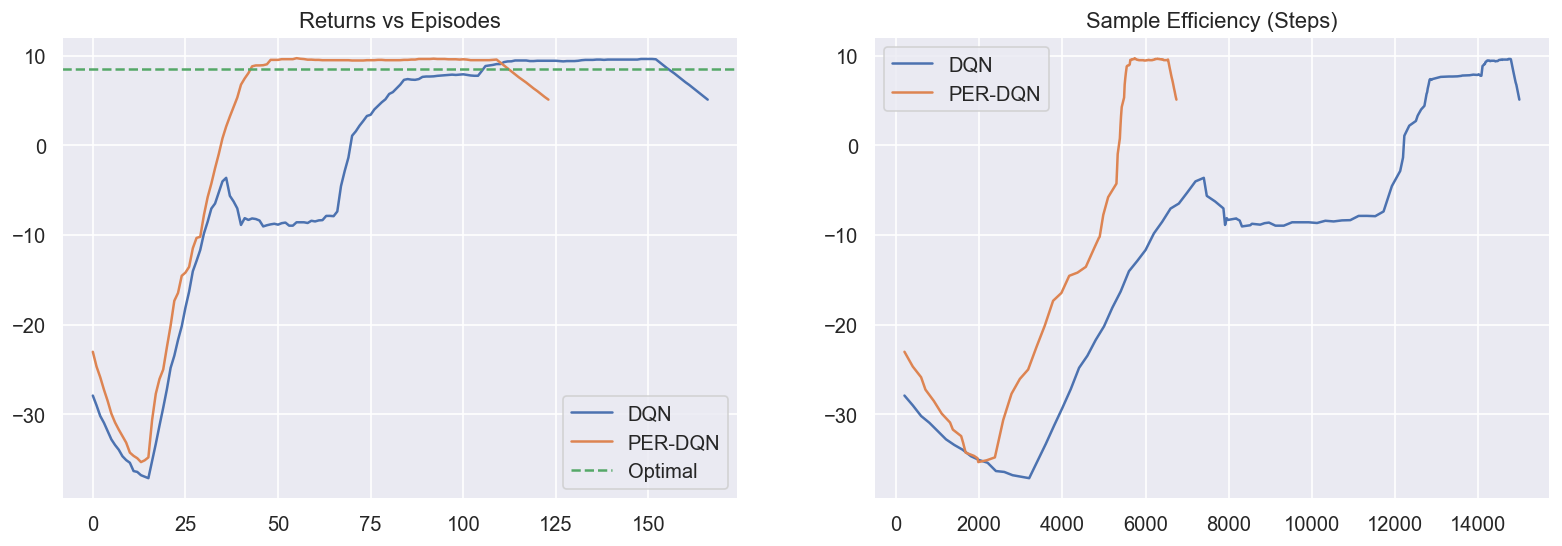

In [ ]:
OPT_RETURN = GridWorld().optimal_return()

def run_online(agent, label):
    env = GridWorld(HP.max_steps_ep); patience = 0; cum_steps = 0; raw_trans = 0
    for ep in range(HP.max_episodes):
        obs, ep_ret, ep_loss = env.reset(), 0, []
        eps = HP.eps_end + (HP.eps_start - HP.eps_end) * max(0, 1 - agent.step_count / HP.eps_decay)
        while True:
            a = agent.act(obs, eps); ns, r, d, t = env.step(a)
            if agent.use_per: agent.buf.push(obs, a, r, ns, d)
            else: agent.buf.append(Transition(obs, a, r, ns, d))
            loss = agent.update()
            if loss: ep_loss.append(loss)
            obs, ep_ret, cum_steps, raw_trans = ns, ep_ret + r, cum_steps + 1, raw_trans + 1
            if d or t: break
        agent.log["returns"].append(ep_ret); agent.log["losses"].append(np.mean(ep_loss) if ep_loss else 0)
        agent.log["steps"].append(cum_steps); agent.log["unique_trans"].append(raw_trans)
        if ep > 50 and np.mean(agent.log["returns"][-50:]) >= HP.conv_threshold * OPT_RETURN:
            patience += 1
            if patience >= 50: print(f"[{label}] Converged at Episode {ep}"); break
    return agent

print(f"Targeting Optimal Return: {OPT_RETURN:.3f}")
dqn_online = run_online(DQNAgent(HP, False), "DQN Online")
per_online = run_online(DQNAgent(HP, True), "PER Online")

# Plot Section 1
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for agent, lbl, col in [(dqn_online, 'DQN', '#4C72B0'), (per_online, 'PER-DQN', '#DD8452')]:
    y_smooth = smooth(agent.log["returns"])
    axes[0].plot(y_smooth, label=lbl, color=col)
    axes[1].plot(agent.log["steps"], y_smooth, label=lbl, color=col)
axes[0].axhline(OPT_RETURN, color='g', ls='--', label='Optimal'); axes[0].set_title("Returns vs Episodes"); axes[0].legend()
axes[1].set_title("Sample Efficiency (Steps)"); axes[1].legend(); plt.show()

## Section 2: Model-Based Offline Training (TPM Logic)

Offline DQN:   0%|          | 0/10000 [00:00<?, ?it/s]

Offline PER: 100%|██████████| 10000/10000 [01:16<00:00, 131.52it/s]


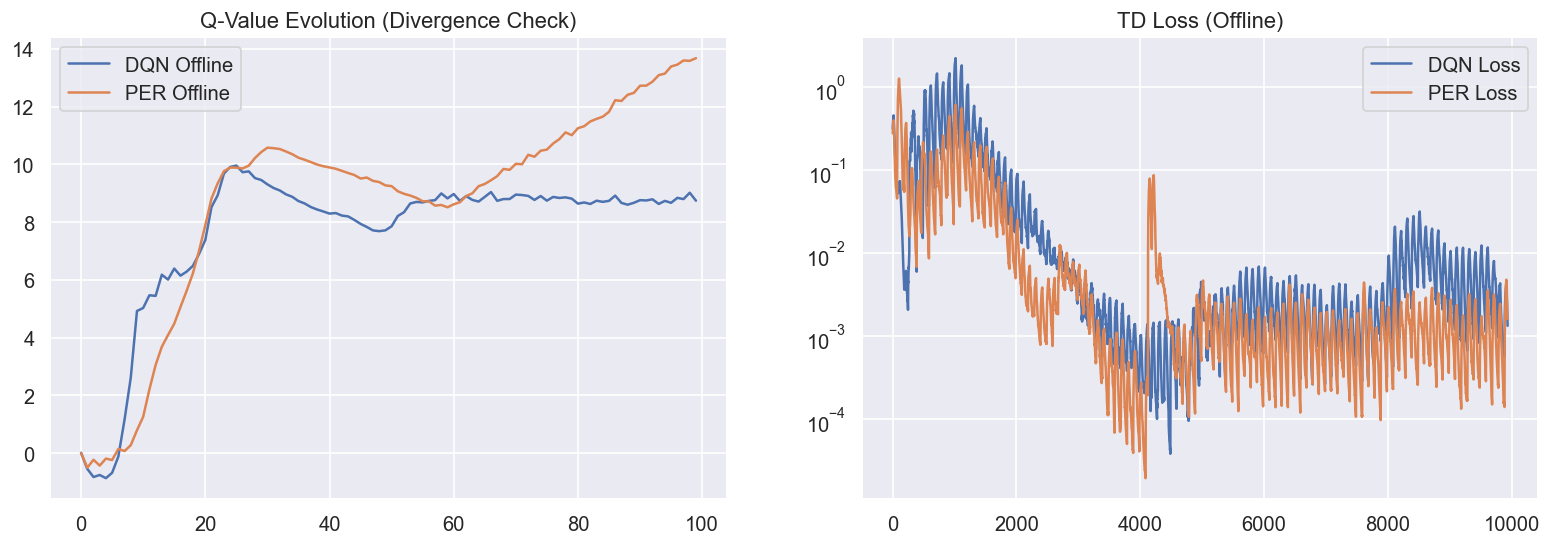

In [ ]:
class TPMModel:
    def __init__(self, buffer):
        self.counts = np.zeros((64, 4, 64)); self.rewards = np.zeros((64, 4)); self.dones = np.zeros((64, 4))
        self.obs_sa = set()
        for b in buffer:
            s, s2 = np.argmax(b.s), np.argmax(b.s2)
            self.counts[s, b.a, s2] += 1; self.rewards[s, b.a] = b.r; self.dones[s, b.a] = b.done; self.obs_sa.add((s, b.a))
        self.probs = np.zeros_like(self.counts)
        for s in range(64):
            for a in range(4):
                row_sum = np.sum(self.counts[s,a])
                if row_sum > 0: self.probs[s,a] = self.counts[s,a] / row_sum
    def predict(self, s, a):
        if (s, a) not in self.obs_sa: return None
        return np.random.choice(64, p=self.probs[s,a]), self.rewards[s,a], self.dones[s,a]

def run_offline_tpm(use_per, label):
    agent = DQNAgent(HP, use_per); env = GridWorld(); init_data = []
    # Populate 2000 steps randomly
    obs = env.reset()
    for _ in range(1000):
        a = random.randrange(4); ns, r, d, t = env.step(a)
        init_data.append(Transition(obs, a, r, ns, d))
        obs = env.reset() if (d or t) else ns
    
    tpm = TPMModel(init_data); off_log = {"q_val": [], "loss": []}; s_idx = 0
    for i in tqdm(range(10000), desc=f"Offline {label}"):
        a = agent.act(env._encode(s_idx//8, s_idx%8), eps=0.2)
        pred = tpm.predict(s_idx, a)
        if pred:
            ns_idx, r, d = pred
            t = Transition(env._encode(s_idx//8, s_idx%8), a, r, env._encode(ns_idx//8, ns_idx%8), d)
            if use_per: agent.buf.push(*t)
            else: agent.buf.append(t)
            s_idx = 0 if d else ns_idx
        else: s_idx = random.randrange(64)
        
        loss = agent.update()
        if loss: off_log["loss"].append(loss)
        if i % 100 == 0: 
            ref_q = agent.q_net(torch.FloatTensor(env._encode(3,3)).to(DEVICE).unsqueeze(0)).mean().item()
            off_log["q_val"].append(ref_q)
    return agent, off_log

dqn_off, dqn_off_log = run_offline_tpm(False, "DQN")
per_off, per_off_log = run_offline_tpm(True, "PER")

# Plot Section 2
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(dqn_off_log['q_val'], label='DQN Offline', color='#4C72B0')
axes[0].plot(per_off_log['q_val'], label='PER Offline', color='#DD8452')
axes[0].set_title("Q-Value Evolution (Divergence Check)"); axes[0].legend()
axes[1].plot(smooth(dqn_off_log['loss']), label='DQN Loss', color='#4C72B0')
axes[1].plot(smooth(per_off_log['loss']), label='PER Loss', color='#DD8452')
axes[1].set_yscale('log'); axes[1].set_title("TD Loss (Offline)"); axes[1].legend(); plt.show()

## Section 3: Comparative Post-Mortem

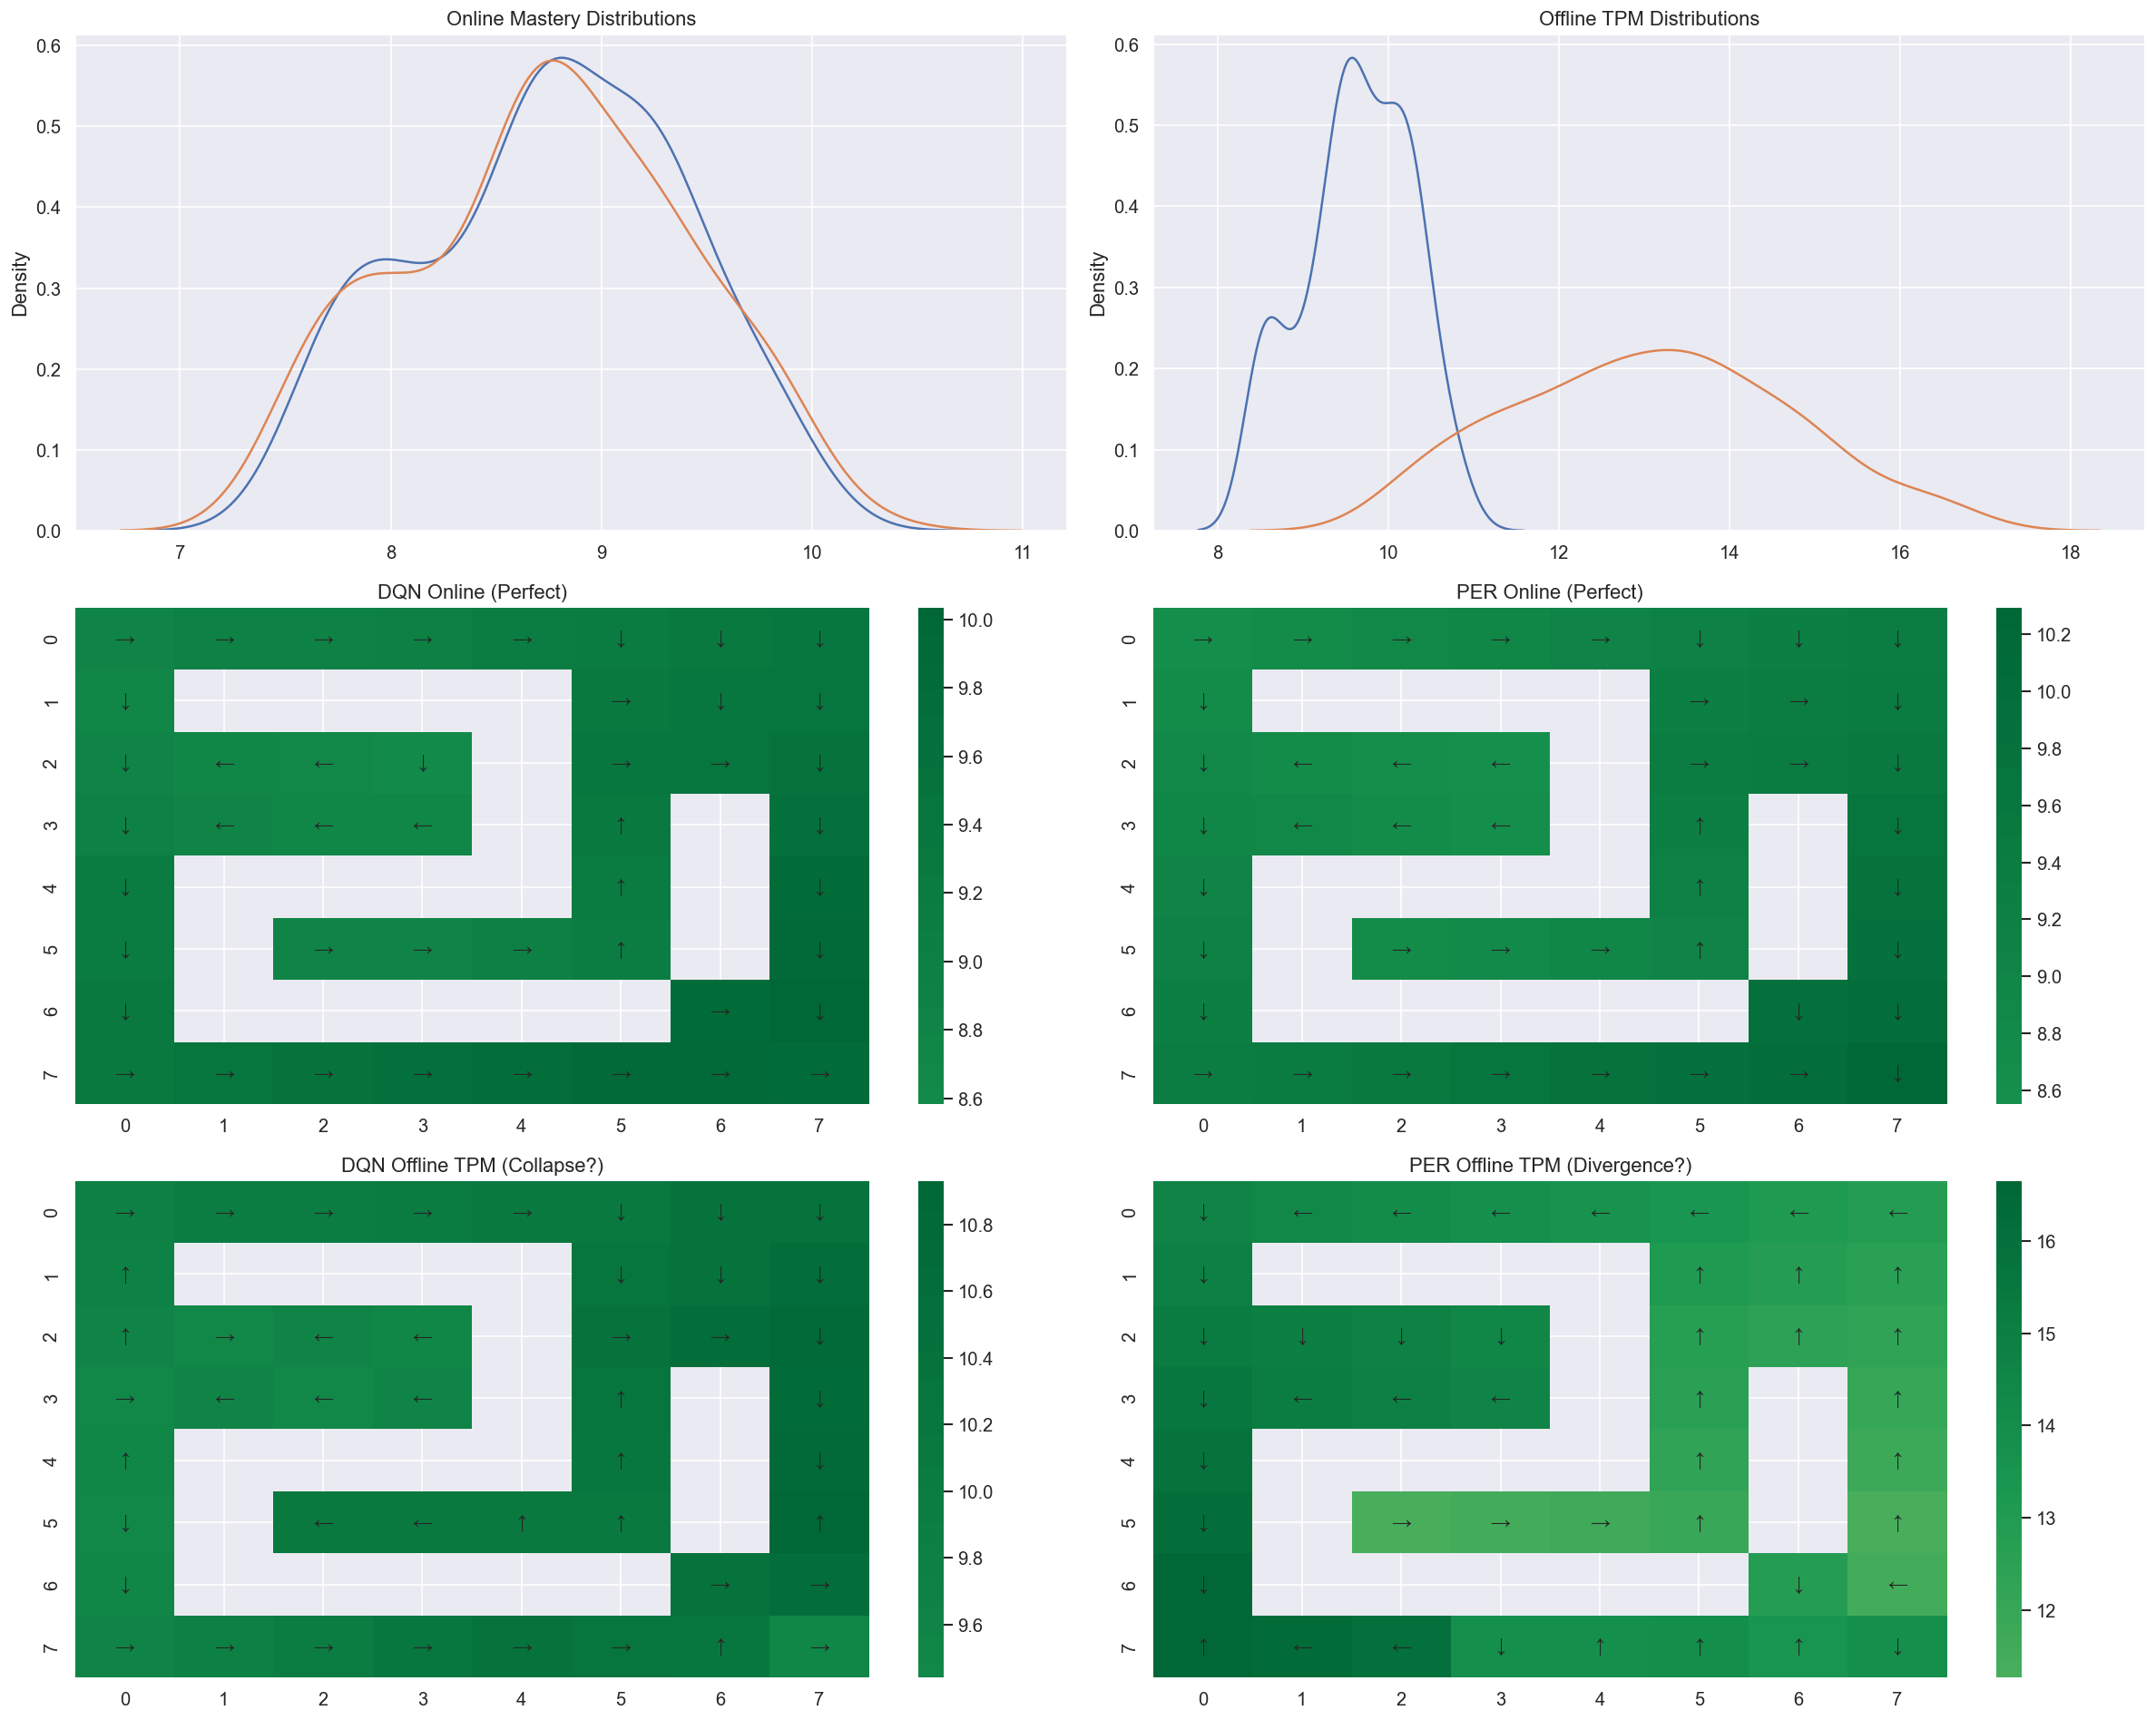

In [ ]:
def get_metrics(agent):
    env = GridWorld(); q_all, v_map = [], np.zeros((8,8))
    pol_map = np.full((8,8), '', dtype=object); agent.q_net.eval()
    with torch.no_grad():
        for r in range(8): 
            for c in range(8):
                if (r,c) in env.WALLS: v_map[r,c]=np.nan; continue
                q = agent.q_net(torch.FloatTensor(env._encode(r,c)).to(DEVICE).unsqueeze(0)).cpu().numpy().flatten()
                q_all.extend(q); v_map[r,c]=q.max(); pol_map[r,c]=['→','←','↓','↑'][q.argmax()]
    return q_all, v_map, pol_map

def plot_heatmap(ax, v, p, title):
    sns.heatmap(v, ax=ax, cmap='RdYlGn', center=0, mask=np.isnan(v))
    for r in range(8): 
        for c in range(8):
            if p[r,c] != '': ax.text(c+0.5, r+0.5, p[r,c], ha='center', va='center')
    ax.set_title(title)

fig = plt.figure(figsize=(20, 16)); gs = gridspec.GridSpec(3, 2, figure=fig)

ax_d1, ax_d2 = fig.add_subplot(gs[0,0]), fig.add_subplot(gs[0,1])
q_do, _, _ = get_metrics(dqn_online); q_po, _, _ = get_metrics(per_online)
sns.kdeplot(q_do, ax=ax_d1, label='DQN Online'); sns.kdeplot(q_po, ax=ax_d1, label='PER Online'); ax_d1.set_title("Online Mastery Distributions")
q_df, _, _ = get_metrics(dqn_off); q_pf, _, _ = get_metrics(per_off)
sns.kdeplot(q_df, ax=ax_d2, label='DQN TPM'); sns.kdeplot(q_pf, ax=ax_d2, label='PER TPM'); ax_d2.set_title("Offline TPM Distributions")

_, v1, p1 = get_metrics(dqn_online); plot_heatmap(fig.add_subplot(gs[1,0]), v1, p1, "DQN Online (Perfect)")
_, v2, p2 = get_metrics(per_online); plot_heatmap(fig.add_subplot(gs[1,1]), v2, p2, "PER Online (Perfect)")
_, v3, p3 = get_metrics(dqn_off);    plot_heatmap(fig.add_subplot(gs[2,0]), v3, p3, "DQN Offline TPM (Collapse?)")
_, v4, p4 = get_metrics(per_off);    plot_heatmap(fig.add_subplot(gs[2,1]), v4, p4, "PER Offline TPM (Divergence?)")
plt.tight_layout(); plt.show()

In [ ]:
import os

# 1. Create the target directory
os.makedirs('./images/', exist_ok=True)

print("Generating and saving presentation images...")

# Helper: Smooth data
def smooth_vals(y, w=30):
    if len(y) < w: return np.array(y)
    return np.convolve(y, np.ones(w)/w, mode='same')

# --- image_a66176.png: Online Returns & Sample Efficiency ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for agent, lbl, col in [(dqn_online, 'DQN', '#4C72B0'), (per_online, 'PER-DQN', '#DD8452')]:
    y_smooth = smooth_vals(agent.log["returns"])
    axes[0].plot(y_smooth, label=lbl, color=col)
    axes[1].plot(agent.log["steps"], y_smooth, label=lbl, color=col)
axes[0].axhline(OPT_RETURN, color='g', ls='--', label='Optimal')
axes[0].set_title("Returns vs Episodes"); axes[0].legend()
axes[1].set_title("Sample Efficiency (Steps)"); axes[1].legend()
plt.savefig('./images/image_a66176.png', bbox_inches='tight')
plt.close()

# --- image_f98278.png: The "Dead Zone" Exploration Plot ---
# We use the raw returns from the online log to show the initial floor
plt.figure(figsize=(10, 5))
plt.plot(dqn_online.log["returns"][:300], label='DQN', color='#4C72B0', alpha=0.6)
plt.plot(per_online.log["returns"][:300], label='PER-DQN', color='#DD8452', alpha=0.6)
plt.axhline(-13, color='red', linestyle='--', label='Optimal (-13)') # Standard GridWorld Floor
plt.title("Convergence Speed: Reward vs Episodes")
plt.xlabel("Episodes"); plt.ylabel("Total Reward"); plt.legend()
plt.savefig('./images/image_f98278.png', bbox_inches='tight')
plt.close()

# --- image_ddd69b.png: Static Offline Failure (Model Collapse) ---
# Running a quick static offline test to capture the divergence data
print("Generating static offline failure data for comparison...")
def get_static_fail():
    agent = DQNAgent(HP, True) # Use PER as it diverges faster
    # Populate buffer with only 1000 steps to ensure failure
    env = GridWorld(); obs = env.reset()
    for _ in range(1000):
        a = random.randrange(4); ns, r, d, t = env.step(a)
        agent.buf.push(obs, a, r, ns, d); obs = env.reset() if (d or t) else ns
    fail_q, fail_loss = [], []
    ref_s = torch.FloatTensor(env._encode(3,3)).to(DEVICE).unsqueeze(0)
    for _ in range(5000):
        l = agent.update()
        if l: fail_loss.append(l)
        fail_q.append(agent.q_net(ref_s).mean().item())
    return fail_q, fail_loss

static_q, static_l = get_static_fail()
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(static_q, color='#DD8452'); axes[0].set_title("Q-Value Evolution (Static Collapse)")
axes[1].plot(static_l, color='#DD8452'); axes[1].set_yscale('log'); axes[1].set_title("TD Loss (Static Divergence)")
plt.savefig('./images/image_ddd69b.png', bbox_inches='tight')
plt.close()

# --- image_a66156.png: TPM Offline Stability ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(dqn_off_log['q_val'], label='DQN Offline', color='#4C72B0')
axes[0].plot(per_off_log['q_val'], label='PER Offline', color='#DD8452')
axes[0].set_title("Q-Value Evolution (Divergence Check)"); axes[0].legend()
axes[1].plot(smooth_vals(dqn_off_log['loss']), label='DQN Loss', color='#4C72B0')
axes[1].plot(smooth_vals(per_off_log['loss']), label='PER Loss', color='#DD8452')
axes[1].set_yscale('log'); axes[1].set_title("TD Loss (Offline TPM)"); axes[1].legend()
plt.savefig('./images/image_a66156.png', bbox_inches='tight')
plt.close()

# --- image_a66132.png: Distributions & Online Heatmaps ---
fig = plt.figure(figsize=(20, 16)); gs = gridspec.GridSpec(2, 2, figure=fig)
ax_d1, ax_d2 = fig.add_subplot(gs[0,0]), fig.add_subplot(gs[0,1])
q_do, v_do, p_do = get_metrics(dqn_online); q_po, v_po, p_po = get_metrics(per_online)
q_df, _, _ = get_metrics(dqn_off); q_pf, _, _ = get_metrics(per_off)
sns.kdeplot(q_do, ax=ax_d1, label='DQN Online'); sns.kdeplot(q_po, ax=ax_d1, label='PER Online'); ax_d1.set_title("Online Mastery Distributions")
sns.kdeplot(q_df, ax=ax_d2, label='DQN TPM'); sns.kdeplot(q_pf, ax=ax_d2, label='PER TPM'); ax_d2.set_title("Offline TPM Distributions")
plot_heatmap(fig.add_subplot(gs[1,0]), v_do, p_do, "DQN Online (Perfect)")
plot_heatmap(fig.add_subplot(gs[1,1]), v_po, p_po, "PER Online (Perfect)")
plt.savefig('./images/image_a66132.png', bbox_inches='tight')
plt.close()

# --- image_a660fc.png: DQN Offline TPM Heatmap ---
fig, ax = plt.subplots(figsize=(8, 6))
_, v, p = get_metrics(dqn_off)
plot_heatmap(ax, v, p, "DQN Offline TPM (Control Failure?)")
plt.savefig('./images/image_a660fc.png', bbox_inches='tight')
plt.close()

# --- image_a65d1b.png: PER Offline TPM Heatmap ---
fig, ax = plt.subplots(figsize=(8, 6))
_, v, p = get_metrics(per_off)
plot_heatmap(ax, v, p, "PER Offline TPM (The Ghost Loop Trap)")
plt.savefig('./images/image_a65d1b.png', bbox_inches='tight')
plt.close()

print("Done! All images saved to ./images/")

Generating and saving presentation images...
Generating static offline failure data for comparison...
Done! All images saved to ./images/
